<a href="https://colab.research.google.com/github/devmofizur/Python/blob/main/Pandas/Read%2C_Write_Excel_and_CSV_Files.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [261]:
from google.colab import drive
import shutil
import os

drive.mount('/content/drive')

source_path = '/content/drive/MyDrive/Colab Notebooks/ML Learning /stock_data.csv'
destination_path = '/content/stock_data.csv'

if os.path.exists(source_path):
    shutil.copy(source_path, destination_path)
    print(f"Successfully copied '{source_path}' to '{destination_path}'")
else:
    print(f"Error: Source file '{source_path}' not found.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Error: Source file '/content/drive/MyDrive/Colab Notebooks/ML Learning /stock_data.csv' not found.


In [262]:
import pandas as pd
import csv

##**Reading csv**

In [263]:
path = destination_path
df= pd.read_csv(path)
df.head()

,Datasource: Google finance,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,tickers,eps,revenue,price,people
1,GOOGL,27.82,87,845,larry page
2,WMT,4.61,484,65,n.a.
3,MSFT,-1,85,64,bill gates
4,RIL,not available,50,1023,mukesh ambani


##**Skipping row**

In [264]:
df= pd.read_csv(path, skiprows=1) # skips one row
# pd.read_csv(path, header=1)  -> sets header to index 1
df

,tickers,eps,revenue,price,people
0,GOOGL,27.82,87,845,larry page
1,WMT,4.61,484,65,n.a.
2,MSFT,-1,85,64,bill gates
3,RIL,not available,50,1023,mukesh ambani
4,TATA,5.6,-1,n.a.,ratan tata


In [265]:
df.columns

Index(['tickers', 'eps', 'revenue', 'price', 'people'], dtype='object')

## **Custom column name**

In [266]:
df = pd.read_csv(path, header=1, names = ['stock_symbols', 'eps', 'revenue', 'price', 'people']) # Changes made on actual column name (tickers -> stock_symbols)
df

,stock_symbols,eps,revenue,price,people
0,GOOGL,27.82,87,845,larry page
1,WMT,4.61,484,65,n.a.
2,MSFT,-1,85,64,bill gates
3,RIL,not available,50,1023,mukesh ambani
4,TATA,5.6,-1,n.a.,ratan tata


##**Specify number of rows to be read**

In [267]:
df = pd.read_csv(path, header=1, names = ['stock_symbols', 'eps', 'revenue', 'price', 'people'], nrows= 5) # read only 5 rows
df

,stock_symbols,eps,revenue,price,people
0,GOOGL,27.82,87,845,larry page
1,WMT,4.61,484,65,n.a.
2,MSFT,-1,85,64,bill gates
3,RIL,not available,50,1023,mukesh ambani
4,TATA,5.6,-1,n.a.,ratan tata


##**Proper NaN value**

In [268]:
df = pd.read_csv(path, header=1, na_values= { 'eps' : ['-1','not available'], 'revenue' : '-1', 'price' : 'n.a.' , 'people' : 'n.a.' }) # specific column specific keywords count as NaN value
df

,tickers,eps,revenue,price,people
0,GOOGL,27.82,87.0,845.0,larry page
1,WMT,4.61,484.0,65.0,NaN
2,MSFT,NaN,85.0,64.0,bill gates
3,RIL,NaN,50.0,1023.0,mukesh ambani
4,TATA,5.60,NaN,NaN,ratan tata


In [269]:
df = pd.read_csv(path, header=1, na_values= ['not available', '-1', 'n.a.' ]) # sspecific keywords count as NaN value through all columns
df

,tickers,eps,revenue,price,people
0,GOOGL,27.82,87.0,845.0,larry page
1,WMT,4.61,484.0,65.0,NaN
2,MSFT,NaN,85.0,64.0,bill gates
3,RIL,NaN,50.0,1023.0,mukesh ambani
4,TATA,5.60,NaN,NaN,ratan tata


In [270]:
df['PE ratio'] = df.price/df.eps
df

,tickers,eps,revenue,price,people,PE ratio
0,GOOGL,27.82,87.0,845.0,larry page,30.373832
1,WMT,4.61,484.0,65.0,NaN,14.099783
2,MSFT,NaN,85.0,64.0,bill gates,NaN
3,RIL,NaN,50.0,1023.0,mukesh ambani,NaN
4,TATA,5.60,NaN,NaN,ratan tata,NaN


In [271]:
df.to_csv('/content/stock_data_with_ratio.csv', index = False)

source_path = '/content/stock_data_with_ratio.csv'
if os.path.exists(source_path):
    print(f"Successfully saved '{source_path}'")
else:
    print(f"Error: Source file '{source_path}' not found.")


Successfully saved '/content/stock_data_with_ratio.csv'


##**Excel**

In [272]:
import pandas as pd
!pip install openpyxl

In [273]:
source_path = ['/content/drive/MyDrive/Colab Notebooks/ML Learning/movies_db.xlsx' , '/content/drive/MyDrive/Colab Notebooks/ML Learning/movies_db_subsheets.png']
destination_path = ['/content/movies_db.xlsx', '/content/movies_db_subsheets.png']

for s,d in zip(source_path, destination_path):
  if os.path.exists(s):
    shutil.copy(s, d)
    print(f"Successfully copied '{s}' to '{d}'")
  else:
    print(f"Error: Source file '{s}' not found.")

Successfully copied '/content/drive/MyDrive/Colab Notebooks/ML Learning/movies_db.xlsx' to '/content/movies_db.xlsx'
Successfully copied '/content/drive/MyDrive/Colab Notebooks/ML Learning/movies_db_subsheets.png' to '/content/movies_db_subsheets.png'


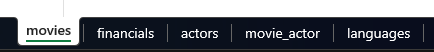

In [274]:
from IPython.display import Image
Image('/content/movies_db_subsheets.png')

In [275]:
df_movies = pd.read_excel(destination_path[0], 'movies')
df_movies.head()

,movie_id,title,industry,release_year,imdb_rating,studio,language_id
0,101,K.G.F: Chapter 2,Bollywood,2022,8.4,Hombale Films,3
1,102,Doctor Strange in the Multiverse of Madness,Hollywood,2022,7.0,Marvel Studios,5
2,103,Thor: The Dark World,Hollywood,2013,6.8,Marvel Studios,5
3,104,Thor: Ragnarok,Hollywood,2017,7.9,Marvel Studios,5
4,105,Thor: Love and Thunder,Hollywood,2022,6.8,Marvel Studios,5


In [276]:
df_movies.shape

(39, 7)

In [277]:
df_financials = pd.read_excel(destination_path[0], 'financials')
df_financials.head()


,movie_id,budget,revenue,unit,currency
0,101,1.0,12.5,Billions,INR
1,102,200.0,954.8,Millions,USD
2,103,165.0,644.8,Millions,$$
3,104,180.0,854.0,Millions,Dollars
4,105,250.0,670.0,Millions,USD


In [278]:
df_financials.shape

(40, 5)

In [279]:
import numpy as np

print(df_financials['currency'].value_counts())
df_financials['currency'] = np.where((df_financials['currency'] == '$$') | (df_financials['currency'] == 'Dollars'), 'USD', df_financials['currency'])

print(df_financials['currency'].value_counts())

currency
USD        20
INR        18
$$          1
Dollars     1
Name: count, dtype: int64
currency
USD    22
INR    18
Name: count, dtype: int64


## **Merging dataframes**

In [280]:
df_merged = pd.merge(df_movies, df_financials, on = 'movie_id')
df_merged.head()

,movie_id,title,industry,release_year,imdb_rating,studio,language_id,budget,revenue,unit,currency
0,101,K.G.F: Chapter 2,Bollywood,2022,8.4,Hombale Films,3,1.0,12.5,Billions,INR
1,102,Doctor Strange in the Multiverse of Madness,Hollywood,2022,7.0,Marvel Studios,5,200.0,954.8,Millions,USD
2,103,Thor: The Dark World,Hollywood,2013,6.8,Marvel Studios,5,165.0,644.8,Millions,USD
3,104,Thor: Ragnarok,Hollywood,2017,7.9,Marvel Studios,5,180.0,854.0,Millions,USD
4,105,Thor: Love and Thunder,Hollywood,2022,6.8,Marvel Studios,5,250.0,670.0,Millions,USD


In [281]:
df_merged.to_excel('/content/movies_db_merged.xlsx', sheet_name='Movies_Merged.xlsx', index = False)

## **Exercise**

In [282]:
source_path = '/content/drive/MyDrive/Colab Notebooks/ML Learning/movies_data.csv'
destination_path = '/content/movies_data.csv'

if os.path.exists(s):
    shutil.copy(source_path, destination_path)
    print(f"Successfully copied '{source_path}' to '{destination_path}'")
else:
    print(f"Error: Source file '{source_path}' not found.")

Successfully copied '/content/drive/MyDrive/Colab Notebooks/ML Learning/movies_data.csv' to '/content/movies_data.csv'


In [283]:
df = pd.read_csv(destination_path)
df.head()

,movie_id,title,industry,language,release_year,imdb_rating,studio,budget,revenue,unit,currency
0,101,K.G.F: Chapter 2,Bollywood,Kannada,2022,8.4,Hombale Films,1.0,12.5,Billions,INR
1,102,Doctor Strange in the Multiverse of Madness,Hollywood,English,2022,7.0,Marvel Studios,200.0,954.8,Millions,USD
2,103,Thor: The Dark World,Hollywood,English,2013,6.8,Marvel Studios,165.0,644.8,Millions,USD
3,104,Thor: Ragnarok,Hollywood,English,2017,7.9,Marvel Studios,180.0,854.0,Millions,USD
4,105,Thor: Love and Thunder,Hollywood,English,2022,6.8,Marvel Studios,250.0,670.0,Millions,USD


In [287]:
df['year_classify'] = np.where(df.release_year < 2000, 'before 2000', 'from 2000')
df

,movie_id,title,industry,language,release_year,imdb_rating,studio,budget,revenue,unit,currency,year_classify
0,101,K.G.F: Chapter 2,Bollywood,Kannada,2022,8.4,Hombale Films,1.00,12.5,Billions,INR,from 2000
1,102,Doctor Strange in the Multiverse of Madness,Hollywood,English,2022,7.0,Marvel Studios,200.00,954.8,Millions,USD,from 2000
2,103,Thor: The Dark World,Hollywood,English,2013,6.8,Marvel Studios,165.00,644.8,Millions,USD,from 2000
3,104,Thor: Ragnarok,Hollywood,English,2017,7.9,Marvel Studios,180.00,854.0,Millions,USD,from 2000
4,105,Thor: Love and Thunder,Hollywood,English,2022,6.8,Marvel Studios,250.00,670.0,Millions,USD,from 2000
5,111,The Shawshank Redemption,Hollywood,English,1994,9.3,Castle Rock Entertainment,25.00,73.3,Millions,USD,before 2000
6,113,Interstellar,Hollywood,English,2014,8.6,Warner Bros. Pictures,165.00,701.8,Millions,USD,from 2000
7,115,The Pursuit of Happyness,Hollywood,English,2006,8.0,Columbia Pictures,55.00,307.1,Millions,USD,from 2000
8,116,Gladiator,Hollywood,English,2000,8.5,Universal Pictures,103.00,460.5,Millions,USD,from 2000
9,117,Titanic,Hollywood,English,1997,7.9,Paramount Pictures,200.00,2202.0,Millions,USD,before 2000


In [291]:
df[['movie_id', 'title', 'budget', 'revenue','year_classify']].to_csv('/content/final_movie_data.csv', index = False)